[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ssindiUCM/SIAM-LS26-MT1/blob/main/DL_Example0_LogisticRegression.ipynb)

---
# Part 2: Interpretable Deep Learning
## SIAM Life Sciences 2026 — Mini-Tutorial

### Where we are

Part 1 of this tutorial covered **traditional machine learning** — logistic regression,
decision trees, cross-validation, model selection. Those methods are *naturally* interpretable:
you can read the coefficients, inspect the decision boundary, and write down what the model does
in closed form.

Part 2 asks: **what about deep learning?**

Neural networks routinely outperform classical methods on complex biological data — image
classification, protein structure, genomics. But a 10-million-parameter CNN does not come with
a readable formula. Does that mean we have to give up on interpretability?

The answer, increasingly, is no. There are three distinct strategies for recovering
interpretability in DL, and each of the following notebooks demonstrates one:

| Strategy | What it asks | Notebook |
|---|---|---|
| **Mechanistic** | Are the building blocks themselves interpretable? | Example 0: A neuron = logistic regression |
| **Attribution** | What did the trained model look at to make this prediction? | Example 1: CNNs + Grad-CAM on medical images |
| **Structural discovery** | Can we use DL to recover interpretable equations from data? | Example 2: REINFORCE for ODE structure learning |

These three strategies are not exhaustive, but they represent the range from
*understanding the model* (mechanistic) to *using the model as a tool to produce understanding*
(structural discovery).

---


# Deep Learning for Biological Modeling
### SIAM Life Sciences 2026 — Example 0: A Single Neuron is Logistic Regression

This notebook demonstrates that a **single neuron with sigmoid activation and binary
cross-entropy loss is exactly logistic regression** — same model, same objective,
just different notation.

We generate synthetic data with **known true parameters**, fit it two ways:
1. Classical logistic regression via `scikit-learn`
2. A single-neuron neural network via TensorFlow

and show that both recover the same weights and bias.

**This is the foundation everything else builds on.**


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, models

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
mpl.rcParams.update({
    'font.family'    : 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size'      : 14,
    'axes.titlesize' : 16,
    'axes.labelsize' : 14,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'     : 120,
})

print("All packages loaded.")
print("TensorFlow:", tf.__version__)


/Users/suzanne/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


All packages loaded.
TensorFlow: 2.20.0


---
## 1. Synthetic Data with Known Ground Truth

We generate binary classification data from a logistic model with **known** parameters:

$$p_i = \sigma(\vec{w}^{*T} \vec{x}_i + b^*), \qquad y_i \sim \text{Bernoulli}(p_i)$$

Because we chose $\vec{w}^*$ and $b^*$, we can check how well each method recovers them.


In [2]:
# ── True parameters ───────────────────────────────────────────────────────────
W_TRUE = np.array([2.0, -1.0, 0.5, -1.5])   # true weights
B_TRUE = 0.3                                  # true bias
N      = 1000                                 # number of samples
N_FEAT = 4                                    # number of features

print("True weights:", W_TRUE)
print("True bias:   ", B_TRUE)

# ── Generate features ─────────────────────────────────────────────────────────
X = np.random.randn(N, N_FEAT).astype(np.float32)

# ── True probabilities and binary labels ──────────────────────────────────────
z    = X @ W_TRUE + B_TRUE
p    = 1 / (1 + np.exp(-z))              # sigmoid
y    = (np.random.rand(N) < p).astype(np.float32)

print(f"\nSamples: {N}  |  Features: {N_FEAT}")
print(f"Class balance: {y.mean():.2f} positive, {1-y.mean():.2f} negative")
print(f"\np(y=1) range: [{p.min():.2f}, {p.max():.2f}]")


True weights: [ 2.  -1.   0.5 -1.5]
True bias:    0.3

Samples: 1000  |  Features: 4
Class balance: 0.53 positive, 0.47 negative

p(y=1) range: [0.00, 1.00]


In [3]:
# ── Train / Validation / Test split  (60 / 20 / 20) ──────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")


Train: 600  |  Val: 200  |  Test: 200


---
## 2. Visualise the Data

We have 4 features — we'll look at pairwise scatter plots for the first two,
coloured by class label.


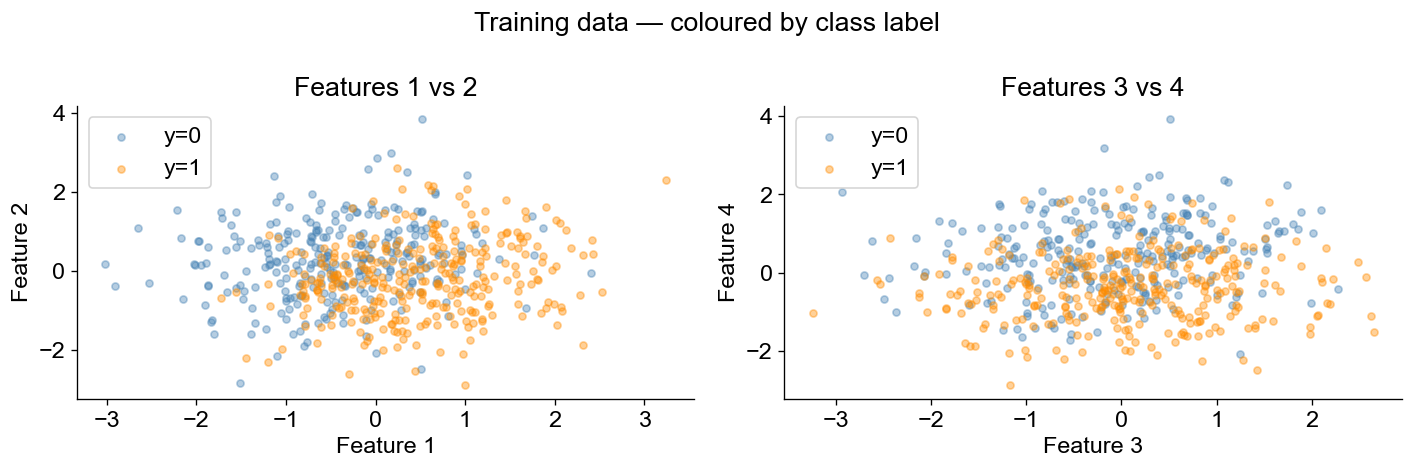

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (fi, fj) in zip(axes, [(0,1), (2,3)]):
    for cls, color, label in [(0,'steelblue','y=0'), (1,'darkorange','y=1')]:
        mask = y_train == cls
        ax.scatter(X_train[mask, fi], X_train[mask, fj],
                   c=color, alpha=0.4, s=18, label=label)
    ax.set_xlabel(f'Feature {fi+1}')
    ax.set_ylabel(f'Feature {fj+1}')
    ax.set_title(f'Features {fi+1} vs {fj+1}')
    ax.legend()

plt.suptitle('Training data — coloured by class label', fontsize=16)
plt.tight_layout()
plt.show()


---
## 3. Classical Logistic Regression (scikit-learn)

We fit logistic regression using `scikit-learn`. This solves:

$$\hat{\vec{w}},\, \hat{b} = \underset{\vec{w},\, b}{\arg\min}\; L(\vec{w}, b)$$

where $L$ is binary cross-entropy — **the same objective as our single neuron**.


In [5]:
# Fit logistic regression (no regularisation, to match the neural network)
lr = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
lr.fit(X_train, y_train)

w_lr = lr.coef_[0]
b_lr = lr.intercept_[0]
acc_lr = accuracy_score(y_test, lr.predict(X_test))

print("── scikit-learn Logistic Regression ──────────────────")
print(f"Recovered weights: {w_lr.round(3)}")
print(f"Recovered bias:    {b_lr:.3f}")
print(f"Test accuracy:     {acc_lr:.4f}")
print()
print(f"True weights:      {W_TRUE}")
print(f"True bias:         {B_TRUE:.3f}")


── scikit-learn Logistic Regression ──────────────────
Recovered weights: [ 2.003 -1.116  0.479 -1.669]
Recovered bias:    0.256
Test accuracy:     0.8200

True weights:      [ 2.  -1.   0.5 -1.5]
True bias:         0.300


---
## 4. Single Neuron Neural Network (TensorFlow)

A single neuron with sigmoid activation:

$$a = \sigma(\vec{w}^T \vec{x} + b) = \left(1 + e^{-(\vec{w}^T \vec{x} + b)}\right)^{-1}$$

This is **one `Dense` layer with 1 unit and sigmoid activation** — nothing more.
Loss: binary cross-entropy. Optimizer: Adam.


In [6]:
# ── Build the model: one neuron ───────────────────────────────────────────────
model = models.Sequential([
    layers.Input(shape=(N_FEAT,)),
    layers.Dense(1, activation='sigmoid',
                 kernel_initializer='glorot_uniform',
                 bias_initializer='zeros')
], name='single_neuron')

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


Model: "single_neuron"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (20.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ── Train ─────────────────────────────────────────────────────────────────────
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=500,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

print(f"Stopped at epoch {len(history.history['loss'])}")


Stopped at epoch 43


In [8]:
# ── Extract recovered parameters ──────────────────────────────────────────────
w_nn = model.layers[0].get_weights()[0].flatten()
b_nn = model.layers[0].get_weights()[1][0]

y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(float)
acc_nn      = accuracy_score(y_test, y_pred)

print("── Single Neuron (TensorFlow) ────────────────────────")
print(f"Recovered weights: {w_nn.round(3)}")
print(f"Recovered bias:    {b_nn:.3f}")
print(f"Test accuracy:     {acc_nn:.4f}")


── Single Neuron (TensorFlow) ────────────────────────
Recovered weights: [ 1.812 -0.949  0.434 -1.509]
Recovered bias:    0.224
Test accuracy:     0.8300


---
## 5. Comparison: Logistic Regression vs. Single Neuron

Both methods solve the same optimisation problem.
If they are equivalent, the recovered parameters should be nearly identical.


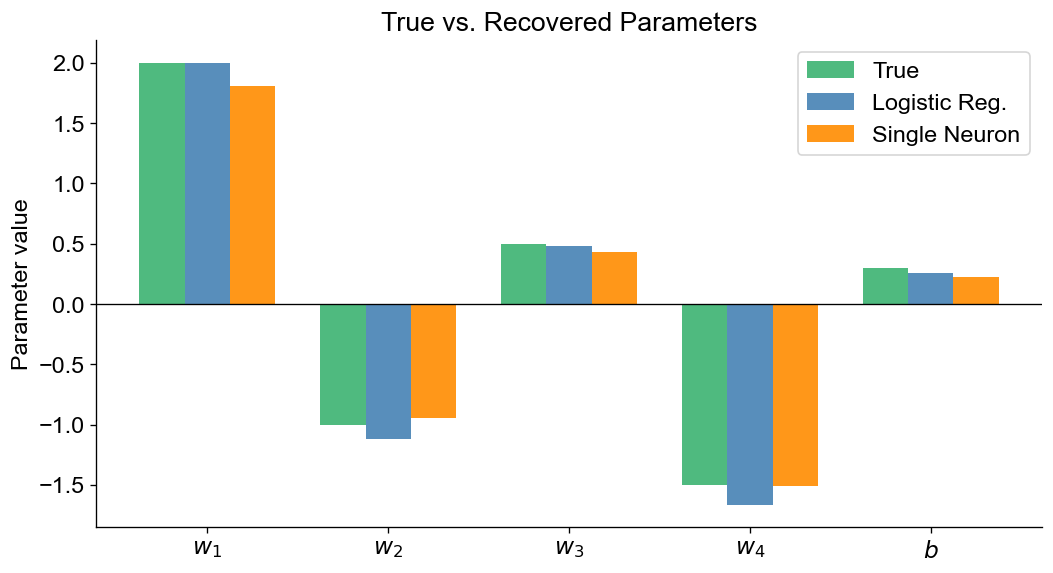


Parameter comparison:
                 True   LogReg   Neuron
----------------------------------------
$w_1$           2.000    2.003    1.812
$w_2$          -1.000   -1.116   -0.949
$w_3$           0.500    0.479    0.434
$w_4$          -1.500   -1.669   -1.509
$b$             0.300    0.256    0.224


In [9]:
feature_names = [f'$w_{i+1}$' for i in range(N_FEAT)] + ['$b$']
true_vals  = list(W_TRUE) + [B_TRUE]
lr_vals    = list(w_lr)   + [b_lr]
nn_vals    = list(w_nn)   + [b_nn]

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(N_FEAT + 1)
width = 0.25

ax.bar(x_pos - width, true_vals, width, label='True',           color='mediumseagreen', alpha=0.9)
ax.bar(x_pos,         lr_vals,   width, label='Logistic Reg.',  color='steelblue',      alpha=0.9)
ax.bar(x_pos + width, nn_vals,   width, label='Single Neuron',  color='darkorange',     alpha=0.9)

ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names, fontsize=14)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Parameter value')
ax.set_title('True vs. Recovered Parameters')
ax.legend()
plt.tight_layout()
plt.savefig('logistic_vs_neuron.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nParameter comparison:")
print(f"{'':12s} {'True':>8} {'LogReg':>8} {'Neuron':>8}")
print("-" * 40)
for name, t, l, n in zip(feature_names, true_vals, lr_vals, nn_vals):
    print(f"{name:12s} {t:8.3f} {l:8.3f} {n:8.3f}")


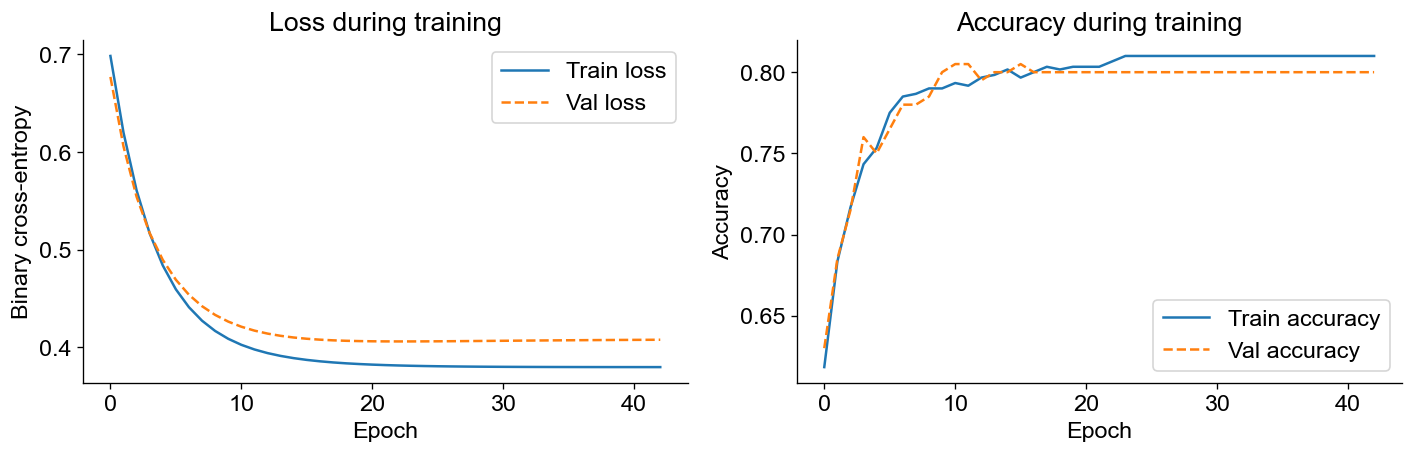

In [10]:
# ── Training curve ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss',  linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary cross-entropy')
axes[0].set_title('Loss during training'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val accuracy', linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy during training'); axes[1].legend()

plt.tight_layout()
plt.savefig('training_curve.png', dpi=200, bbox_inches='tight')
plt.show()


---
## 6. Summary

| | scikit-learn | Single Neuron (TF) |
|--|-------------|-------------------|
| Model | Logistic regression | `Dense(1, activation='sigmoid')` |
| Loss | Binary cross-entropy | Binary cross-entropy |
| Optimizer | L-BFGS | Adam |
| Parameters | $\vec{w} \in \mathbb{R}^4$, $b \in \mathbb{R}$ | Same |
| Test accuracy | See above | See above |

**Key takeaway:** a single neuron with sigmoid activation and binary cross-entropy loss
*is* logistic regression. The neural network framework generalises this by stacking
many such neurons — the single neuron is the base case.

Everything that follows (MLP, CNN, Grad-CAM, BINNs) builds on this foundation.


---
## Discussion

**Exercises** — try changing one thing at a time and observe what happens:

1. Change `N_FEAT` from 4 to 6 and `N_INFORM` from 2 to 4. Do both methods recover the correct weights for the new informative features?
2. Add L2 regularization to the TF neuron: `keras.regularizers.l2(0.01)` on the kernel. How do the recovered weights change compared to logistic regression?
3. Change the learning rate or number of epochs for the TF neuron. At what point does it match logistic regression's parameter estimates?
4. Change the class balance so that one class has 90% of the samples. How do both methods respond?
5. Run the notebook several times with different random seeds. Are both methods consistent in which weights they recover?
